c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Subset size: 4000 (2000 per classe)

Carico teacher...


BertSdpaSelfAttention is used but `torch.nn.functional.scaled_dot_product_attention` does not support non-absolute `position_embedding_type` or `output_attentions=True` or `head_mask`. Falling back to the manual attention implementation, but specifying the manual implementation will be required from Transformers version v5.0.0 onwards. This warning can be removed using the argument `attn_implementation="eager"` when loading the model.



Carico student fase 2...

Plot salvato: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\notebooks\attention_entropy_plot.png

── Summary Attention Entropy ──────────────────────────────────
Layer        Teacher mean  Teacher std
  L0               4.3670       0.5415
  L1               3.6715       0.3890
  L2               3.1645       0.2800
  L3               3.0212       0.2041
  L4               2.5771       0.1806
  L5               1.7170       0.1143
  L6               1.8885       0.1165
  L7               1.6855       0.1385
  L8               2.3953       0.2281
  L9               2.9866       0.3841
  L10              3.2392       0.5114
  L11              3.7497       0.5936

Layer        Student mean  Student std  (layer originale student)
  L0               3.6345       0.3594
  L1               1.9419       0.1658
  L2               2.6894       0.2540
  L3               3.7570       0.5809

Media globale  Teacher : 2.8719
Media globale  Student : 3.0057
Riduzione en

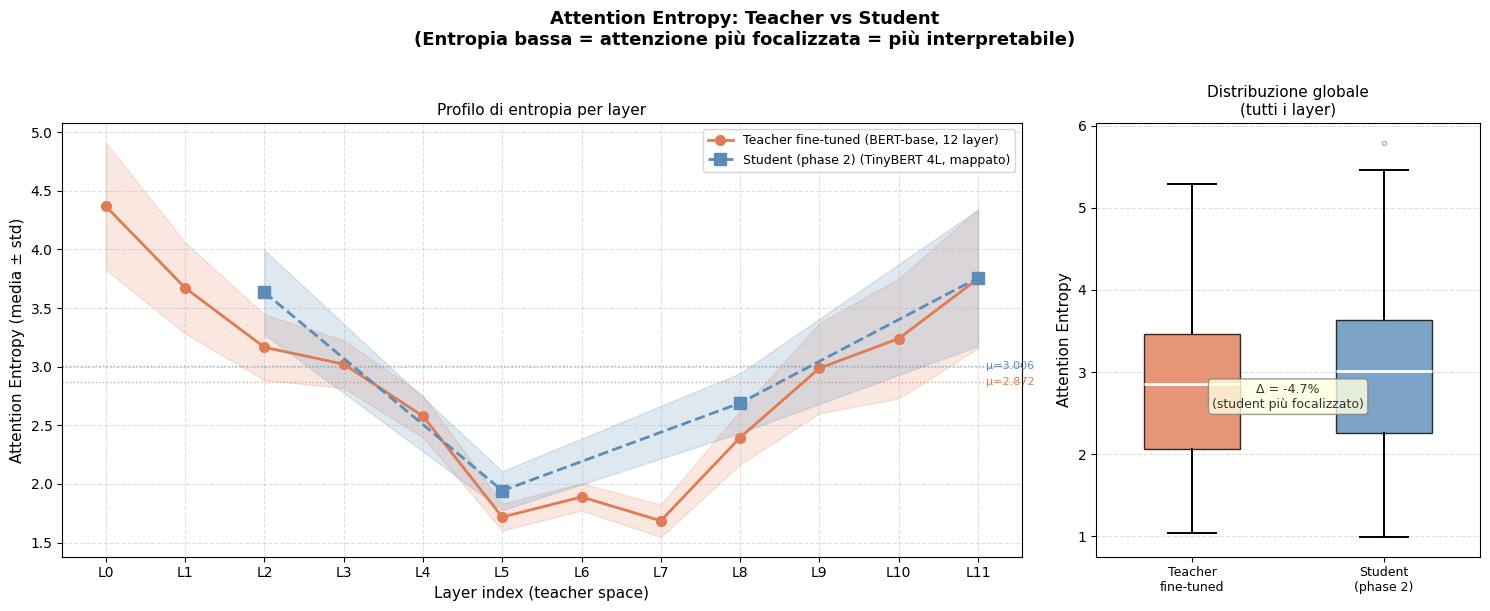

In [1]:
"""
Attention Entropy Analysis: Teacher (BERT-base) vs Student (TinyBERT)
======================================================================
Calcola e plotta l'attention entropy per layer per entrambi i modelli,
con un campione bilanciato del test set (spoiler vs no-spoiler).

Attention Entropy:
  H(a) = - sum_j a_j * log(a_j + eps)
  
  - Entropia alta  → attenzione diffusa su molti token (meno interpretabile)
  - Entropia bassa → attenzione concentrata su pochi token (più interpretabile)

Output: attention_entropy_plot.png
"""

import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datasets import load_dataset
from transformers import AutoModelForSequenceClassification, DataCollatorWithPadding, AutoTokenizer

# ── Path setup ────────────────────────────────────────────────────────────────
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

teacher_path      = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
phase1_ckpt_path  = CKPT_DIR / "tinybert_phase1"        / "checkpoint-57856"
student_phase2    = CKPT_DIR / "tinybert_phase2"         / "checkpoint-13000"

assert teacher_path.exists(),     f"Non esiste: {teacher_path}"
assert phase1_ckpt_path.exists(), f"Non esiste: {phase1_ckpt_path}"

# ── Config ────────────────────────────────────────────────────────────────────
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
N_SAMPLES  = 2000      # campione bilanciato per classe
BATCH_SIZE = 16
SEED       = 42
OUTPUT_PNG = Path("attention_entropy_plot.png")

print(f"Device: {DEVICE}")

# ── Carica test set ───────────────────────────────────────────────────────────
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

# Campione bilanciato
rng = np.random.default_rng(SEED)
idx_0 = np.where(np.array(test_ds["labels"]) == 0)[0]
idx_1 = np.where(np.array(test_ds["labels"]) == 1)[0]
n     = min(N_SAMPLES, len(idx_0), len(idx_1))
idx   = np.concatenate([
    rng.choice(idx_0, n, replace=False),
    rng.choice(idx_1, n, replace=False),
])
rng.shuffle(idx)
subset = test_ds.select(idx.tolist())
subset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
print(f"Subset size: {len(subset)} ({n} per classe)")

# ── Helper: collate con padding dinamico ─────────────────────────────────────
# Usiamo direttamente il tokenizer del teacher (stesso vocabolario)
tokenizer = AutoTokenizer.from_pretrained(str(teacher_path))
collator  = DataCollatorWithPadding(tokenizer, return_tensors="pt")
loader    = DataLoader(subset, batch_size=BATCH_SIZE, collate_fn=collator)


# ── Helper: estrai attention da un modello ────────────────────────────────────
def compute_entropy_per_layer(model, loader, device):
    """
    Restituisce un dict  { layer_idx: np.array di entropie per sample }
    Ogni sample contribuisce con la media su tutte le teste e tutti i token.
    """
    model.eval()
    model.to(device)
    n_layers = model.config.num_hidden_layers
    layer_entropies = {l: [] for l in range(n_layers)}

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_attentions=True,
            )
            # outputs.attentions: tuple di (batch, heads, seq, seq) per layer
            for l, attn in enumerate(outputs.attentions):
                # attn: (B, H, L, L)  — già softmax-ati dal modello HF
                # Mascheriamo i token di padding prima di calcolare l'entropia
                mask = attention_mask.bool()  # (B, L)

                # Entropy per head: -sum_j a_j * log(a_j) → (B, H, L)
                eps  = 1e-9
                ent  = -(attn * torch.log(attn + eps)).sum(dim=-1)  # (B, H, L)

                # Media su heads e token (solo token reali, non padding)
                # Espandiamo la maschera su H
                mask_expanded = mask.unsqueeze(1).expand_as(ent)   # (B, H, L)
                ent_masked = (ent * mask_expanded).sum(dim=(1, 2)) # (B,)
                count      = mask_expanded.sum(dim=(1, 2)).float()  # (B,)
                ent_per_sample = (ent_masked / count).cpu().numpy()

                layer_entropies[l].extend(ent_per_sample.tolist())

    return {l: np.array(v) for l, v in layer_entropies.items()}


# ── Carica teacher ────────────────────────────────────────────────────────────
print("\nCarico teacher...")
teacher = AutoModelForSequenceClassification.from_pretrained(str(teacher_path))
teacher_entropy = compute_entropy_per_layer(teacher, loader, DEVICE)
del teacher
torch.cuda.empty_cache()

# ── Carica student (fase 2 se esiste, altrimenti fase 1) ─────────────────────
if student_phase2.exists():
    student_ckpt = student_phase2
    student_label = "Student (phase 2)"
    print("\nCarico student fase 2...")
else:
    student_ckpt = phase1_ckpt_path
    student_label = "Student (phase 1)"
    print("\nCarico student fase 1...")

student = AutoModelForSequenceClassification.from_pretrained(str(student_ckpt))
student_entropy = compute_entropy_per_layer(student, loader, DEVICE)
del student
torch.cuda.empty_cache()


# ── Plot ──────────────────────────────────────────────────────────────────────
TEACHER_COLOR = "#E07B54"   # arancio caldo
STUDENT_COLOR = "#5B8DB8"   # blu medio

t_layers = sorted(teacher_entropy.keys())   # 0..11
s_layers = sorted(student_entropy.keys())   # 0..3

t_means = [teacher_entropy[l].mean() for l in t_layers]
t_stds  = [teacher_entropy[l].std()  for l in t_layers]
s_means = [student_entropy[l].mean() for l in s_layers]
s_stds  = [student_entropy[l].std()  for l in s_layers]

fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         gridspec_kw={"width_ratios": [2.5, 1]})
fig.suptitle("Attention Entropy: Teacher vs Student\n"
             "(Entropia bassa = attenzione più focalizzata = più interpretabile)",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel sinistro: profilo per layer ────────────────────────────────────────
ax = axes[0]

# Teacher
x_t = np.arange(len(t_layers))
ax.plot(x_t, t_means, "o-", color=TEACHER_COLOR, lw=2, ms=7,
        label="Teacher fine-tuned (BERT-base, 12 layer)")
ax.fill_between(x_t,
                np.array(t_means) - np.array(t_stds),
                np.array(t_means) + np.array(t_stds),
                color=TEACHER_COLOR, alpha=0.18)

# Student — lo allineiamo sul range 0-11 usando la mapping g(m)
# Mapping usato in distillazione (TinyBERT 4L → BERT 12L): layer m → g(m)
# Tipicamente: [3, 6, 9, 12] → indici 2,5,8,11
mapping = {0: 2, 1: 5, 2: 8, 3: 11}
x_s = np.array([mapping[m] for m in s_layers])
ax.plot(x_s, s_means, "s--", color=STUDENT_COLOR, lw=2, ms=8,
        label=f"{student_label} (TinyBERT 4L, mappato)")
ax.fill_between(x_s,
                np.array(s_means) - np.array(s_stds),
                np.array(s_means) + np.array(s_stds),
                color=STUDENT_COLOR, alpha=0.20)

ax.set_xlabel("Layer index (teacher space)", fontsize=11)
ax.set_ylabel("Attention Entropy (media ± std)", fontsize=11)
ax.set_title("Profilo di entropia per layer", fontsize=11)
ax.set_xticks(range(12))
ax.set_xticklabels([f"L{i}" for i in range(12)])
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.4)

# Annota media globale
t_global = np.mean([v for arr in teacher_entropy.values() for v in arr])
s_global = np.mean([v for arr in student_entropy.values() for v in arr])
ax.axhline(t_global, color=TEACHER_COLOR, lw=1, ls=":", alpha=0.7)
ax.axhline(s_global, color=STUDENT_COLOR, lw=1, ls=":", alpha=0.7)
ax.text(11.1, t_global, f"μ={t_global:.3f}", color=TEACHER_COLOR, va="center", fontsize=8)
ax.text(11.1, s_global, f"μ={s_global:.3f}", color=STUDENT_COLOR, va="center", fontsize=8)

# ── Panel destro: boxplot globale ────────────────────────────────────────────
ax2 = axes[1]

all_teacher = np.concatenate([teacher_entropy[l] for l in t_layers])
all_student = np.concatenate([student_entropy[l] for l in s_layers])

bp = ax2.boxplot(
    [all_teacher, all_student],
    patch_artist=True,
    widths=0.5,
    medianprops=dict(color="white", lw=2),
    whiskerprops=dict(lw=1.4),
    capprops=dict(lw=1.4),
    flierprops=dict(marker="o", markersize=3, alpha=0.3),
)
bp["boxes"][0].set_facecolor(TEACHER_COLOR)
bp["boxes"][1].set_facecolor(STUDENT_COLOR)
bp["boxes"][0].set_alpha(0.8)
bp["boxes"][1].set_alpha(0.8)

ax2.set_xticks([1, 2])
ax2.set_xticklabels(["Teacher\nfine-tuned", student_label.replace(" (", "\n(")], fontsize=9)
ax2.set_ylabel("Attention Entropy", fontsize=11)
ax2.set_title("Distribuzione globale\n(tutti i layer)", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.4, axis="y")

# Annota la differenza percentuale
delta_pct = (t_global - s_global) / t_global * 100
ax2.annotate(
    f"Δ = {delta_pct:.1f}%\n(student più focalizzato)",
    xy=(1.5, min(t_global, s_global)),
    ha="center", va="top",
    fontsize=9,
    color="#333333",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8),
)

plt.tight_layout()
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nPlot salvato: {OUTPUT_PNG.resolve()}")

# ── Stampa summary numerico ───────────────────────────────────────────────────
print("\n── Summary Attention Entropy ──────────────────────────────────")
print(f"{'Layer':<10} {'Teacher mean':>14} {'Teacher std':>12}")
for l in t_layers:
    print(f"  L{l:<7} {teacher_entropy[l].mean():>14.4f} {teacher_entropy[l].std():>12.4f}")
print(f"\n{'Layer':<10} {'Student mean':>14} {'Student std':>12}  (layer originale student)")
for m in s_layers:
    print(f"  L{m:<7} {student_entropy[m].mean():>14.4f} {student_entropy[m].std():>12.4f}")
print(f"\nMedia globale  Teacher : {t_global:.4f}")
print(f"Media globale  Student : {s_global:.4f}")
print(f"Riduzione entropia     : {delta_pct:.2f}%")

c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Caricamento modelli in corso...
Calcolo dell'entropia sui batch...


100%|██████████| 1959/1959 [07:27<00:00,  4.38it/s]
C:\Users\cola0\AppData\Local\Temp\ipykernel_14900\3713675366.py:125: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Model', y='Attention Entropy', data=df, palette=['#1f77b4', '#ff7f0e'])


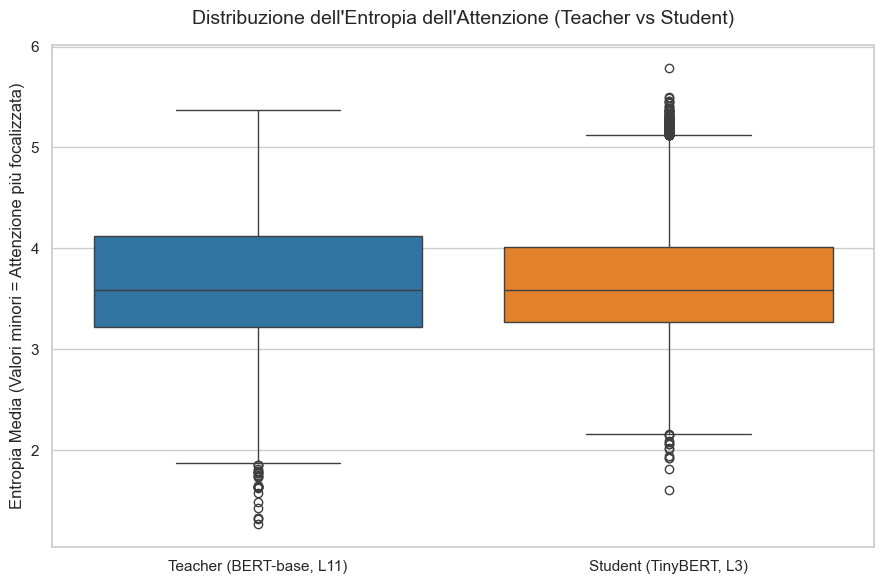

Media Teacher: 3.6484
Media Student: 3.6628


In [1]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from tqdm import tqdm

# --- 1. Setup Paths (Dal tuo codice) ---
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))
from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

# === Checkpoint paths ===
teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
# Usiamo il Phase 2 perché vogliamo analizzare il modello finale che fa classificazione
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000" 

assert teacher_path.exists(), f"Non esiste: {teacher_path}"
assert student_phase2_path.exists(), f"Non esiste: {student_phase2_path}"

# --- 2. Caricamento Modelli (con output_attentions=True) ---
print("Caricamento modelli in corso...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Teacher
teacher = AutoModelForSequenceClassification.from_pretrained(
    teacher_path, output_attentions=True
).to(device)
teacher.eval()

# Student
student = AutoModelForSequenceClassification.from_pretrained(
    student_phase2_path, output_attentions=True
).to(device)
student.eval()

tokenizer = AutoTokenizer.from_pretrained(teacher_path)

# --- 3. Preparazione Dati ---
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

# Opzionale: Prendi un sottoinsieme casuale per velocizzare il calcolo (es. 1000 recensioni)
# test_ds = test_ds.shuffle(seed=42).select(range(1000))

collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
# Rimuoviamo colonne non necessarie per il collator se presenti (es. text)
cols_to_keep = ["input_ids", "attention_mask", "labels", "token_type_ids"]
cols_to_remove = [c for c in test_ds.column_names if c not in cols_to_keep]
test_ds_clean = test_ds.remove_columns(cols_to_remove)

dataloader = DataLoader(test_ds_clean, batch_size=16, collate_fn=collator)

# --- 4. Funzione per l'Entropia ---
def compute_attention_entropy(attentions, attention_mask):
    """
    Calcola l'entropia media dell'attenzione per ogni sequenza nel batch.
    attentions shape: (batch_size, num_heads, seq_len, seq_len)
    """
    eps = 1e-9 # Per evitare log(0)
    
    # Entropia di Shannon per ogni distribuzione di attenzione: H = - sum( p * log(p) )
    # Lo calcoliamo sull'ultima dimensione (i token su cui si sta prestando attenzione)
    entropy = -torch.sum(attentions * torch.log(attentions + eps), dim=-1) # Shape: (batch, heads, seq_len)
    
    # Facciamo la media tra le varie teste (heads)
    mean_head_entropy = entropy.mean(dim=1) # Shape: (batch, seq_len)
    
    # Vogliamo l'entropia media della frase, ma dobbiamo escludere i token di padding [PAD]
    # attention_mask vale 1 per i token validi e 0 per il padding
    sum_entropy = (mean_head_entropy * attention_mask).sum(dim=1)
    valid_tokens = attention_mask.sum(dim=1)
    
    avg_entropy_per_sequence = sum_entropy / valid_tokens # Shape: (batch,)
    return avg_entropy_per_sequence.cpu().numpy()

# --- 5. Estrazione Attenzioni e Calcolo ---
teacher_entropies = []
student_entropies = []

print("Calcolo dell'entropia sui batch...")
with torch.no_grad():
    for batch in tqdm(dataloader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        # Passaggio Teacher
        t_outputs = teacher(input_ids=input_ids, attention_mask=attention_mask)
        # Prendiamo l'attenzione dell'ultimo layer (indice -1)
        t_attn = t_outputs.attentions[-1] 
        t_ent = compute_attention_entropy(t_attn, attention_mask)
        teacher_entropies.extend(t_ent)
        
        # Passaggio Student
        s_outputs = student(input_ids=input_ids, attention_mask=attention_mask)
        # Prendiamo l'attenzione dell'ultimo layer dello student (indice -1)
        s_attn = s_outputs.attentions[-1]
        s_ent = compute_attention_entropy(s_attn, attention_mask)
        student_entropies.extend(s_ent)

# --- 6. Creazione del Grafico ---
# Creiamo un DataFrame Pandas per facilitare il plotting con Seaborn
df = pd.DataFrame({
    'Model': ['Teacher (BERT-base, L11)'] * len(teacher_entropies) + 
             ['Student (TinyBERT, L3)'] * len(student_entropies),
    'Attention Entropy': np.concatenate([teacher_entropies, student_entropies])
})

# Stile del grafico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(9, 6))

# Puoi usare sns.violinplot se preferisci vedere la densità, 
# ma il boxplot è più standard per i report
ax = sns.boxplot(x='Model', y='Attention Entropy', data=df, palette=['#1f77b4', '#ff7f0e'])

plt.title('Distribuzione dell\'Entropia dell\'Attenzione (Teacher vs Student)', fontsize=14, pad=15)
plt.ylabel('Entropia Media (Valori minori = Attenzione più focalizzata)', fontsize=12)
plt.xlabel('')

# Salvataggio del grafico per poterlo inserire comodamente nel report
plt.tight_layout()
plt.savefig('attention_entropy_comparison.png', dpi=300)
plt.show()

print(f"Media Teacher: {np.mean(teacher_entropies):.4f}")
print(f"Media Student: {np.mean(student_entropies):.4f}")

Caricamento modelli...
Calcolo Integrated Gradients su 200 samples...


100%|██████████| 200/200 [01:34<00:00,  2.12it/s]


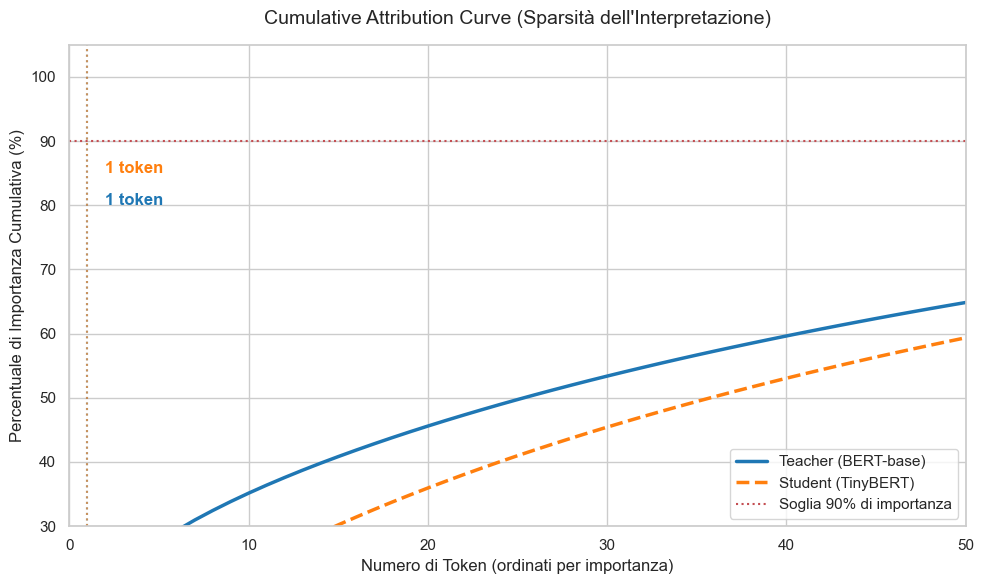


Risultati per raggiungere il 90% di importanza decisionale:
- Teacher: 1 token
- Student: 1 token


In [6]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from captum.attr import LayerIntegratedGradients
from tqdm import tqdm

# --- 1. Setup Paths ---
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))
from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

# --- 2. Caricamento Modelli ---
print("Caricamento modelli...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device)
teacher.eval()

student = AutoModelForSequenceClassification.from_pretrained(student_phase2_path).to(device)
student.eval()

tokenizer = AutoTokenizer.from_pretrained(teacher_path)

# --- 3. Preparazione Dati (Prendiamo un sample ridotto) ---
# L'attribuzione richiede il calcolo dei gradienti ed è computazionalmente intensa.
# 200 recensioni sono statisticamente sufficienti per generare curve stabili.
NUM_SAMPLES = 200

test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

test_ds = test_ds.shuffle(seed=42).select(range(NUM_SAMPLES))
cols_to_keep = ["input_ids", "attention_mask", "labels", "token_type_ids"]
test_ds_clean = test_ds.remove_columns([c for c in test_ds.column_names if c not in cols_to_keep])

# Usiamo batch_size=1 per Integrated Gradients per evitare problemi di padding
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
dataloader = DataLoader(test_ds_clean, batch_size=1, collate_fn=collator)

# --- 4. Setup Captum (Integrated Gradients) ---
# Dobbiamo definire una funzione forward custom che accetti gli input_ids
def forward_func_teacher(input_ids, attention_mask):
    return teacher(input_ids=input_ids, attention_mask=attention_mask).logits

def forward_func_student(input_ids, attention_mask):
    return student(input_ids=input_ids, attention_mask=attention_mask).logits

# Inizializziamo Integrated Gradients sul layer di embedding delle parole
lig_teacher = LayerIntegratedGradients(forward_func_teacher, teacher.get_input_embeddings())
lig_student = LayerIntegratedGradients(forward_func_student, student.get_input_embeddings())

# --- 5. Funzione per calcolare la curva cumulativa ---
MAX_TOKENS_PLOT = 100 # Guardiamo ai top 100 token più importanti

def process_attributions(attributions, mask):
    # Sommiamo le attribuzioni lungo la dimensione dell'embedding (es. da 768 a 1)
    token_attr = attributions.sum(dim=-1).squeeze(0).abs().cpu().numpy()
    valid_mask = mask.squeeze(0).cpu().numpy() == 1
    
    # Escludiamo il padding
    valid_attr = token_attr[valid_mask]
    
    # Ordiniamo i token per importanza assoluta (decrescente)
    sorted_attr = np.sort(valid_attr)[::-1]
    
    # Normalizziamo affinché la somma totale faccia 1 (100%)
    total_attr = sorted_attr.sum()
    if total_attr == 0:
        return np.ones(MAX_TOKENS_PLOT)
        
    cum_attr = np.cumsum(sorted_attr) / total_attr
    
    # Tronchiamo o paddiamo la curva a MAX_TOKENS_PLOT
    padded_curve = np.ones(MAX_TOKENS_PLOT)
    length = min(len(cum_attr), MAX_TOKENS_PLOT)
    padded_curve[:length] = cum_attr[:length]
    
    return padded_curve

# --- 6. Estrazione Attribuzioni ---
teacher_curves = []
student_curves = []

print(f"Calcolo Integrated Gradients su {NUM_SAMPLES} samples...")
for batch in tqdm(dataloader):
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    
    # Cerchiamo di spiegare la classe predetta dal modello (o target)
    with torch.no_grad():
        target_t = teacher(input_ids=input_ids, attention_mask=attention_mask).logits.argmax(dim=-1).item()
        target_s = student(input_ids=input_ids, attention_mask=attention_mask).logits.argmax(dim=-1).item()
    
# Calcolo per Teacher
    attr_t = lig_teacher.attribute(inputs=input_ids, target=target_t, additional_forward_args=(attention_mask,), n_steps=20, internal_batch_size=1)
    curve_t = process_attributions(attr_t, attention_mask)
    teacher_curves.append(curve_t)
    
    # Calcolo per Student
    attr_s = lig_student.attribute(inputs=input_ids, target=target_s, additional_forward_args=(attention_mask,), n_steps=20, internal_batch_size=1)
    curve_s = process_attributions(attr_s, attention_mask)
    student_curves.append(curve_s)

# Calcoliamo la media delle curve
mean_teacher_curve = np.mean(teacher_curves, axis=0) * 100 # in percentuale
mean_student_curve = np.mean(student_curves, axis=0) * 100

# --- 7. Plot del Grafico ---
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

x_axis = np.arange(1, MAX_TOKENS_PLOT + 1)

plt.plot(x_axis, mean_teacher_curve, label='Teacher (BERT-base)', linewidth=2.5, color='#1f77b4')
plt.plot(x_axis, mean_student_curve, label='Student (TinyBERT)', linewidth=2.5, color='#ff7f0e', linestyle='--')

# Aggiungiamo la linea del 90%
plt.axhline(y=90, color='r', linestyle=':', label='Soglia 90% di importanza')

# Troviamo quanti token servono per il 90%
tokens_90_teacher = np.argmax(mean_teacher_curve >= 90) + 1
tokens_90_student = np.argmax(mean_student_curve >= 90) + 1

plt.axvline(x=tokens_90_teacher, color='#1f77b4', linestyle=':', alpha=0.6)
plt.axvline(x=tokens_90_student, color='#ff7f0e', linestyle=':', alpha=0.6)

plt.title("Cumulative Attribution Curve (Sparsità dell'Interpretazione)", fontsize=14, pad=15)
plt.xlabel("Numero di Token (ordinati per importanza)", fontsize=12)
plt.ylabel("Percentuale di Importanza Cumulativa (%)", fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.xlim(0, 50) # Mostriamo solo i primi 50 token per maggiore chiarezza
plt.ylim(30, 105)

# Evidenziamo il risultato sul grafico
plt.text(tokens_90_student + 1, 85, f'{tokens_90_student} token', color='#ff7f0e', fontweight='bold')
plt.text(tokens_90_teacher + 1, 80, f'{tokens_90_teacher} token', color='#1f77b4', fontweight='bold')

plt.tight_layout()
plt.savefig('cumulative_attribution_curve.png', dpi=300)
plt.show()

print(f"\nRisultati per raggiungere il 90% di importanza decisionale:")
print(f"- Teacher: {tokens_90_teacher} token")
print(f"- Student: {tokens_90_student} token")

In [9]:
import sys
from pathlib import Path
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers_interpret import SequenceClassificationExplainer

# --- 1. Setup Paths ---
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))
from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

# --- 2. Caricamento Modelli e Tokenizer ---
print("Caricamento modelli...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(teacher_path)

teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path).to(device)
teacher.eval()

student = AutoModelForSequenceClassification.from_pretrained(student_phase2_path).to(device)
student.eval()

# --- 3. Selezione di una Recensione ---
# Carichiamo il test set e prendiamo una recensione (es. la numero 42, o cercane una con "spoiler")
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

# Troviamo la prima recensione che è effettivamente uno Spoiler (label == 1)
spoiler_idx = next(i for i, label in enumerate(test_ds['labels']) if label == 1)
sample = test_ds[spoiler_idx]

# Ricostruiamo il testo in chiaro dai token ID (ignorando i token speciali come [PAD])
text_to_explain = tokenizer.decode(sample['input_ids'], skip_special_tokens=True)
true_label = "Spoiler" if sample['labels'] == 1 else "No Spoiler"

print(f"\nAnalizzando recensione all'indice {spoiler_idx}")
print(f"True Label: {true_label}")
print(f"Testo (troncato): {text_to_explain}\n")

# --- 4. Setup Transformers Interpret ---
# Inizializziamo gli explainer
cls_explainer_teacher = SequenceClassificationExplainer(
    teacher, 
    tokenizer,
    custom_labels=["No Spoiler", "Spoiler"] # <-- Modificato qui
)

cls_explainer_student = SequenceClassificationExplainer(
    student, 
    tokenizer,
    custom_labels=["No Spoiler", "Spoiler"] # <-- Modificato qui
)

# --- 5. Estrazione e Salvataggio Visualizzazioni ---
print("Calcolo attribuzioni Teacher...")
word_attributions_t = cls_explainer_teacher(text_to_explain)

print("Calcolo attribuzioni Student...")
word_attributions_s = cls_explainer_student(text_to_explain)

# Salviamo i risultati in file HTML (potrai aprirli nel browser e fare uno screenshot per il report)
cls_explainer_teacher.visualize("teacher_explanation.html")
cls_explainer_student.visualize("student_explanation.html")

print("\nFinito! Apri i file 'teacher_explanation.html' e 'student_explanation.html' nel tuo browser.")

Caricamento modelli...

Analizzando recensione all'indice 0
True Label: Spoiler
Testo (troncato): i would have eventually gotten around to watching this film, but my curiosity was piqued when i saw that it had miraculously jumped to number # 17 on the 2007 version of afi ' s top 100 movies of all time list. it didn ' t make the cut at all for the original compilation in 1997, so even before seeing the picture, i had to wonder what might have affected movie critics in the intervening decade to reach this conclusion. i usually line up with the majority in most cases, but i have to admit, i don ' t quite get it with this picture. i found it entertaining enough on occasion, but i never was the most expensive ever made for a silent film, and i have to give keaton credit for going out on that kind of a limb - unbelievable. oh yes, and i can ' t forget the sequence where keaton ' s marksmanship is dead on when he makes contact with the rail tie blocking the train tracks, flipping it out of th


Finito! Apri i file 'teacher_explanation.html' e 'student_explanation.html' nel tuo browser.


Caricamento modelli in corso...


Analisi bert: 100%|██████████| 25/25 [00:02<00:00,  9.95it/s]


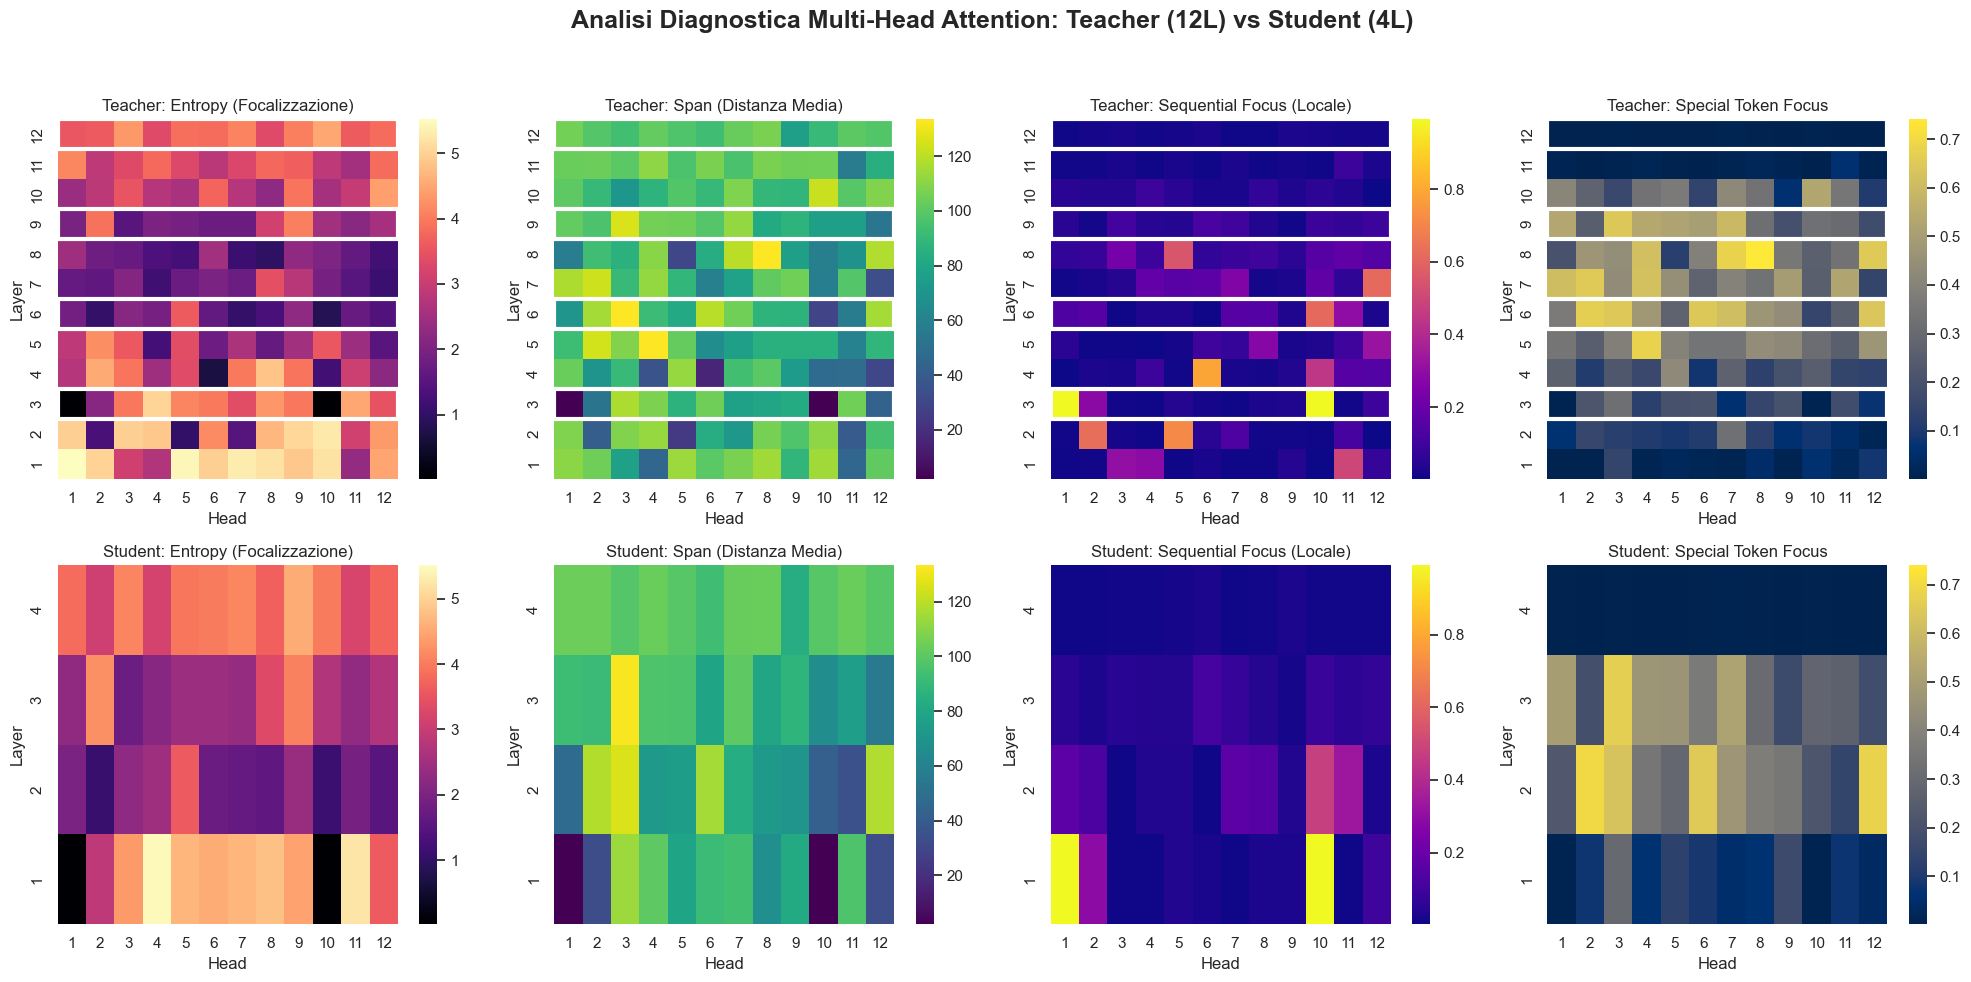


Dashboard generata e salvata come 'multihead_diagnostic_matrices_highlighted.png'


In [11]:
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding
from tqdm import tqdm

# --- 1. Setup Paths ---
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))
from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
student_phase2_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

# --- 2. Caricamento Modelli ---
print("Caricamento modelli in corso...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(teacher_path)

# IMPORTANTE: output_attentions=True per estrarre le matrici
teacher = AutoModelForSequenceClassification.from_pretrained(teacher_path, output_attentions=True).to(device)
teacher.eval()

student = AutoModelForSequenceClassification.from_pretrained(student_phase2_path, output_attentions=True).to(device)
student.eval()

# --- 3. Preparazione Dati ---
NUM_SAMPLES = 200 # Campione sufficiente per avere stabilità statistica
test_ds = load_dataset("parquet", data_files=str(DATA_DIR / "test.parquet"))["train"]
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

test_ds = test_ds.shuffle(seed=42).select(range(NUM_SAMPLES))
cols_to_keep = ["input_ids", "attention_mask", "labels"]
test_ds_clean = test_ds.remove_columns([c for c in test_ds.column_names if c not in cols_to_keep])

collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")
dataloader = DataLoader(test_ds_clean, batch_size=8, collate_fn=collator)

# --- 4. Funzioni per Metriche Diagnostiche Multi-Head ---
def compute_metrics_for_model(model, dataloader):
    num_layers = model.config.num_hidden_layers
    num_heads = model.config.num_attention_heads
    
    # Inizializziamo accumulatori per le 4 metriche (shape: num_layers, num_heads)
    entropy_acc = np.zeros((num_layers, num_heads))
    span_acc = np.zeros((num_layers, num_heads))
    seq_acc = np.zeros((num_layers, num_heads))
    special_acc = np.zeros((num_layers, num_heads))
    total_batches = 0
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc=f"Analisi {model.config.model_type}"):
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device) # (B, S)
            
            outputs = model(input_ids=input_ids, attention_mask=mask)
            attentions = outputs.attentions # Tupla di (B, H, S, S)
            
            seq_len = input_ids.size(1)
            
            # Matrice delle distanze per calcolare lo Span |i - j|
            idx = torch.arange(seq_len, device=device)
            dist_matrix = torch.abs(idx.unsqueeze(0) - idx.unsqueeze(1)).float() # (S, S)
            
            # Maschera per token sequenziali (|i - j| == 1)
            seq_mask = (dist_matrix == 1).float()
            
            # Maschera per special tokens (101=[CLS], 102=[SEP] in BERT)
            special_tokens = ((input_ids == 101) | (input_ids == 102)).float() # (B, S)
            
            for l_idx, att in enumerate(attentions):
                # att shape: (B, H, S, S) -> probabilità dal token i (dim 2) al token j (dim 3)
                
                # 1. Entropy: -sum(p * log(p))
                ent = -torch.sum(att * torch.log(att + 1e-12), dim=-1) # (B, H, S)
                
                # 2. Span (Distanza Media): sum(p * dist)
                span = torch.sum(att * dist_matrix.unsqueeze(0).unsqueeze(0), dim=-1) # (B, H, S)
                
                # 3. Sequential Focus (peso sui token adiacenti)
                seq = torch.sum(att * seq_mask.unsqueeze(0).unsqueeze(0), dim=-1) # (B, H, S)
                
                # 4. Special Token Focus (peso assegnato a CLS e SEP)
                spec = torch.sum(att * special_tokens.unsqueeze(1).unsqueeze(2), dim=-1) # (B, H, S)
                
                # Aggregazione ignorando i token di padding come 'query'
                # mask è (B, S), la espandiamo a (B, 1, S)
                valid_mask = mask.unsqueeze(1) 
                
                avg_ent = (ent * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                avg_span = (span * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                avg_seq = (seq * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                avg_spec = (spec * valid_mask).sum(dim=(0, 2)) / valid_mask.sum()
                
                entropy_acc[l_idx] += avg_ent.cpu().numpy()
                span_acc[l_idx] += avg_span.cpu().numpy()
                seq_acc[l_idx] += avg_seq.cpu().numpy()
                special_acc[l_idx] += avg_spec.cpu().numpy()
                
            total_batches += 1
            
    return (entropy_acc / total_batches, 
            span_acc / total_batches, 
            seq_acc / total_batches, 
            special_acc / total_batches)

# Estraiamo le metriche
t_metrics = compute_metrics_for_model(teacher, dataloader)
s_metrics = compute_metrics_for_model(student, dataloader)

import matplotlib.patches as patches

# --- 5. Visualizzazione (Dashboard Multi-Head) ---
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
fig.suptitle("Analisi Diagnostica Multi-Head Attention: Teacher (12L) vs Student (4L)", fontsize=18, fontweight='bold', y=0.98)

metric_names = ["Entropy (Focalizzazione)", "Span (Distanza Media)", "Sequential Focus (Locale)", "Special Token Focus"]
cmaps = ["magma", "viridis", "plasma", "cividis"]

for col_idx, (m_name, cmap) in enumerate(zip(metric_names, cmaps)):
    # --- Teacher (Riga 0) ---
    sns.heatmap(t_metrics[col_idx], ax=axes[0, col_idx], cmap=cmap, cbar=True,
                yticklabels=range(1, 13), xticklabels=range(1, 13))
    axes[0, col_idx].set_title(f"Teacher: {m_name}")
    axes[0, col_idx].set_ylabel("Layer")
    axes[0, col_idx].set_xlabel("Head")
    axes[0, col_idx].invert_yaxis() # Layer 1 in basso, 12 in alto
    
    # MODIFICA: Aggiunta del contorno bianco per i layer di distillazione (3, 6, 9, 12)
    distillation_layers = [3, 6, 9, 12]
    for layer in distillation_layers:
        # L'indice y per il rettangolo parte da layer-1 (es. il layer 3 è alla y=2)
        y_pos = layer - 1
        # Disegniamo un rettangolo trasparente con bordo bianco spesso 3 pixel
        rect = patches.Rectangle((0, y_pos), 12, 1, fill=False, edgecolor='white', lw=3)
        axes[0, col_idx].add_patch(rect)
    
    # --- Student (Riga 1) ---
    # Lo student ha 4 layer, ma manteniamo lo stesso range di colori del teacher per un confronto equo
    vmin, vmax = t_metrics[col_idx].min(), t_metrics[col_idx].max()
    sns.heatmap(s_metrics[col_idx], ax=axes[1, col_idx], cmap=cmap, cbar=True, vmin=vmin, vmax=vmax,
                yticklabels=range(1, 5), xticklabels=range(1, 13))
    axes[1, col_idx].set_title(f"Student: {m_name}")
    axes[1, col_idx].set_ylabel("Layer")
    axes[1, col_idx].set_xlabel("Head")
    axes[1, col_idx].invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("multihead_diagnostic_matrices_highlighted.png", dpi=300)
plt.show()

print("\nDashboard generata e salvata come 'multihead_diagnostic_matrices_highlighted.png'")